[ENG]

PROJECT 2: BREAST CANCER - DECISION TREES AND PERFORMANCE METRICS

[FR]

PROJET 2 : CANCER DU SEIN - ARBRES DE DECISION ET METRIQUES DE PERFORMANCE

**Attribute Information:**

    1) ID number
    2) Diagnosis (M = malignant, B = benign)
    3-32)

**Ten real-valued features are computed for each cell nucleus:**

    a) radius (mean of distances from center to points on the perimeter)
    b) texture (standard deviation of gray-scale values)
    c) perimeter
    d) area
    e) smoothness (local variation in radius lengths)
    f) compactness (perimeter^2 / area - 1.0)
    g) concavity (severity of concave portions of the contour)
    h) concave points (number of concave portions of the contour)
    i) symmetry
    j) fractal dimension ("coastline approximation" - 1)

**The mean, standard error and "worst" or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 features. For instance, field 3 is Mean Radius, field 13 is Radius SE, field 23 is Worst Radius.**

**All feature values are recoded with four significant digits.**

**Missing attribute values: none**

**Class distribution: 357 benign, 212 malignant**


[ENG]

EXERCISE 1 : HOLD OUT METHOD

[FR]

EXERCICE 1 : METHODE DU HOLD OUT

In [33]:
# Packages
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [34]:
# Open dataset
cancer_df= pd.read_csv("C://Users//emmhu//OneDrive//Documents//E-LEARNING//DU DATA ANALYST//4_Introduction au ML supervisé//Données//Project_2_Cancer//cancer.csv")
cancer_df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [35]:
# Observing data structure
cancer_df.shape

(569, 33)

In [36]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [37]:
cancer_df.describe(include='all')

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.037183e+07,NaN,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,NaN,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,NaN,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,NaN,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,NaN,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN


In [38]:
print(cancer_df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

[ENG]

1. Randomly divide the dataset by train test split, using the following ratio: 80% for training and 20% for testing. The training base will be called X train and will only include the ‘features’ (i.e. not the information needed to determine whether the tumour is benign or malignant), while y train will include the ‘labels’. At this stage, you will only use radius mean and concave points mean as training variables. In the case of y train, you will ensure that the value 1 is assigned to malignant tumours, and 0 to benign tumours. You then construct X test and y test in a similar way.

[FR]

1. Divisez aléatoirement le jeu de données via train test split, en suivant le ratio suivant : 80% pour l’entraînement, et 20% pour le test. La base d’entraînement sera nommée X train et ne comprendra que les ”features” (i.e., pas l’information permettant de d´ eterminer si la tumeur est bégnine ou maligne), tandis que y train comportera les ”labels”. A ce stade, vous n’utiliserez que radius mean, et le nombre de points concaves (concave points mean) comme variables pour l’entraînement. Dans le cas de y train, vous ferez en sorte que la valeur 1 soit attribuée aux tumeurs malignes, et 0 aux bégnines. Vous construirez ensuite X test et y test de manière analogue.

In [39]:
# Select relevant columns and separate features (X) and target (y)
cancer_filtered= cancer_df[["radius_mean", "concave points_mean", "diagnosis"]]

X= cancer_filtered[["radius_mean", "concave points_mean"]]
y= cancer_filtered["diagnosis"]

# Define class names for use in plot_tree
class_names= ['Benign','Malignant']

[ENG]

2. Import DecisionTreeClassifier from sklearn.tree

[FR]

2. Importez DecisionTreeClassifier depuis sklearn.tree

In [40]:
# Split the dataset into 80 % train, 20% test
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2, random_state=4, stratify= y)

[ENG]

3. Set up a classifier called dt. The maximum depth of the tree must be 6. Set a seed to 1 (random state=1) in order to obtain reproducible results

[FR]

3. Instanciez un classifieur nommé dt. La profondeur maximale de l’arbre doit être de 6. Définissez une seed à 1 (random state=1) afin d’obtenir des résultats reproductibles

In [41]:
# Instantiate the DecisionTreeClassifier
dt= DecisionTreeClassifier(max_depth= 6, random_state= 4)

[ENG]

4. Train dt on the training dataset (X_train and y_train)

[FR]

4. Entraînez dt sur le jeu de données d’entraînement (X_train et y_train)

In [42]:
# Fit the model to the training set
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=4)

[ENG]

5. Once dt has been trained, use it to predict whether tumours are benign or malignant, then display the results for the first five values

[FR]

5. Une fois dt entraîné, utilisez-le pour prédire le caractère bénin ou malin des tumeurs, puis affichez les résultats pour les cinq premières valeurs

In [43]:
# Predict probabilities of getting one status
tumor_proba= dt.predict_proba(X_test)

In [44]:
# Retrieve class names corresponding to diagnosis
class_labels= dt.classes_

In [45]:
# Display the results for the first five test samples
print("First five test samples' predictions and probabilities:")
for i in range(5):
    print(f"Sample {i+1}:")
    print(f"  Probability (Benign, Malignant): {tumor_proba[i]}")
    print("\n")

First five test samples' predictions and probabilities:
Sample 1:
  Probability (Benign, Malignant): [1. 0.]


Sample 2:
  Probability (Benign, Malignant): [0. 1.]


Sample 3:
  Probability (Benign, Malignant): [1. 0.]


Sample 4:
  Probability (Benign, Malignant): [0.91666667 0.08333333]


Sample 5:
  Probability (Benign, Malignant): [1. 0.]




### Model Prediction probabilities for first five test samples

The output above displays the **predicted class probabilities** for the first five samples in the test dataset. The model is trained to classify tumors as **Benign** (label 0) or **Malignant** (label 1), and the results are reported as probability vectors in the format *(Benign, Malignant)*:

- **Sample 1** and **Sample 3**: Both predicted as **Benign** with 100% confidence (`[1. 0.]`).
- **Sample 2** and **Sample 5**: Predicted as **Malignant** with 100% confidence (`[0. 1.]`).
- **Sample 4**: The only case with **non-extreme probabilities**, with ~91.7% confidence for **Benign** and ~8.3% for **Malignant** (`[0.91666667 0.08333333]`), indicating slight uncertainty.

#### Key insights

- The model makes **confident, discrete predictions** for most cases, outputting near-binary probabilities.
- Sample 4 suggests a **soft prediction**, which may benefit from threshold tuning or post-analysis depending on the application (e.g., in high-risk medical settings).
- Such outputs are particularly useful for **ROC curve analysis**, **threshold adjustment**, and **calibration assessment**.


[ENG]

6. Display the corresponding classification tree

[FR]

6. Affichez l’arbre de classification correspondant

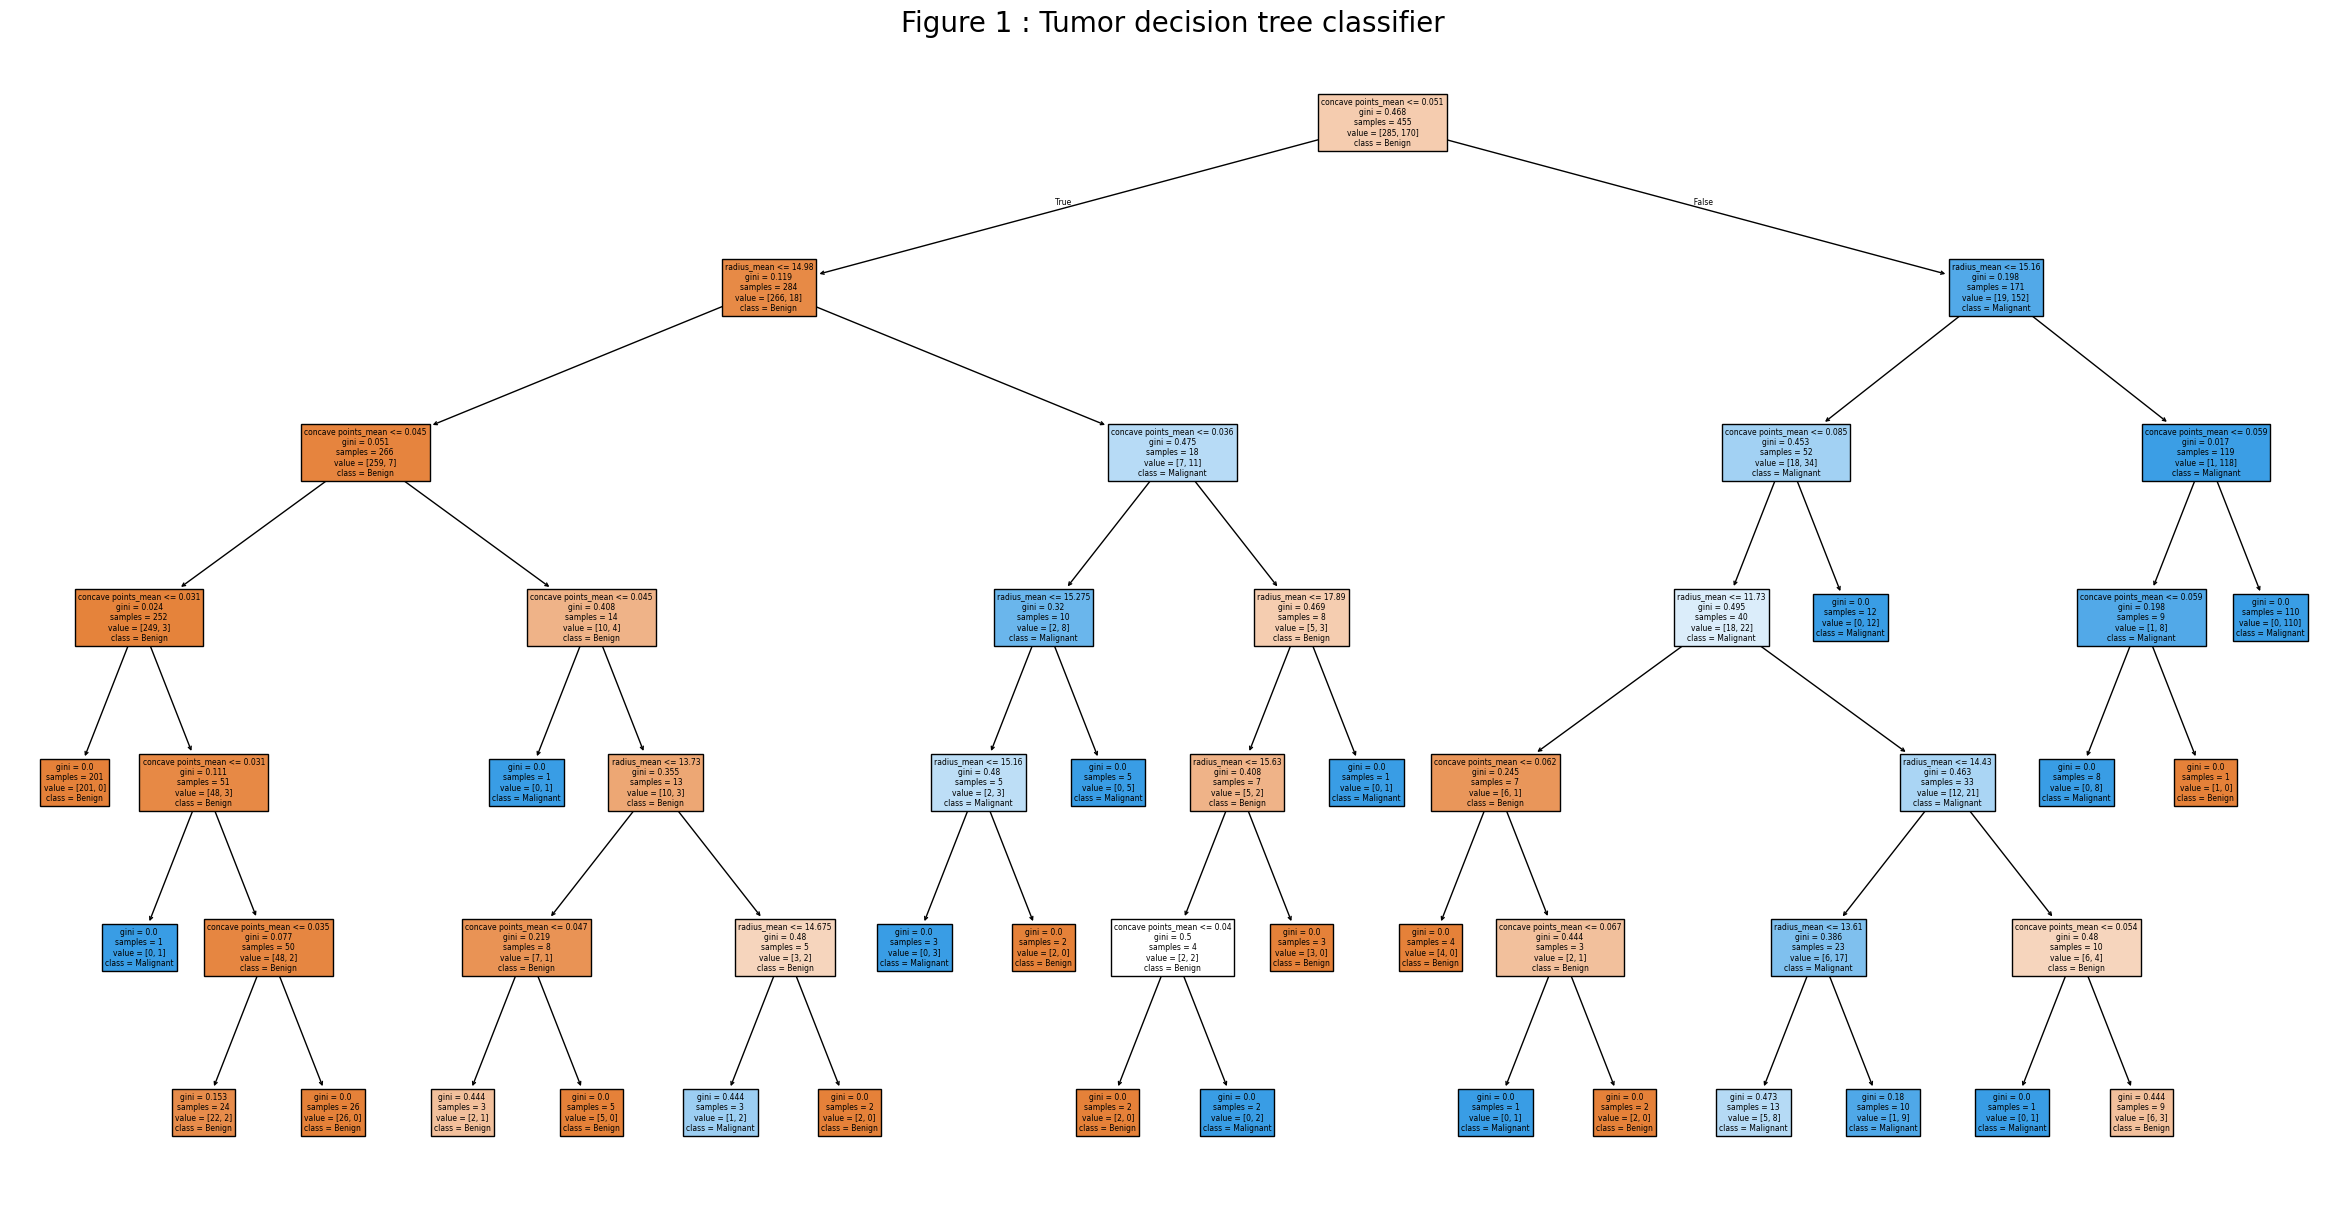

In [46]:
# Plot the decision tree
plt.figure(figsize=(30,15))

plot_tree(dt, max_depth= 6, feature_names= ["radius_mean", "concave points_mean"], class_names= class_names, label='all',filled=True, impurity=True, 
          node_ids=False, proportion=False, rounded=False, precision=3, ax=None, fontsize=None)
plt.title("Figure 1 : Tumor decision tree classifier", fontsize=20)

plt.savefig("Figure1_Tumor_decision_tree_classifier.png", dpi=300, bbox_inches='tight')

plt.show()

### Figure 1: Tumor classification using a decision tree classifier

This diagram visualizes a trained **decision tree classifier** used to predict whether a tumor is **Benign** (orange) or **Malignant** (blue), based on various input features from medical imaging data.

Each node represents a **decision rule** based on a feature threshold (e.g., `concave points_mean`, `radius_mean`, `area_mean`, etc.). The decision tree splits the data hierarchically:
- **Top nodes** correspond to the most informative features,
- **Leaf nodes** at the bottom represent the final classification outcomes.

Key information at each node includes:
- **Gini impurity**: A measure of class purity; 0 indicates pure (only one class present),
- **Samples**: Number of data points reaching the node,
- **Value**: Class distribution at the node (Benign, Malignant),
- **Class**: Final prediction for that node.

#### Key Insights
- The tree prioritizes features like `concave points_mean` and `radius_mean` as key decision drivers.
- **Color shading** reflects the purity of classification: darker nodes are more confident (lower Gini).
- This structure provides a **transparent and interpretable** model, making it suitable for **medical decision support**, where explainability is critical.
- However, deep trees may risk **overfitting**, especially if not properly pruned or validated.

This figure effectively demonstrates how a decision tree partitions the feature space to classify tumors based on measurable characteristics.


[ENG]

7. What problem(s) does the hold-out method pose?

[FR]

7. Quel(s) problème(s) pose(nt) la méthode du hold out ?

### Limitations of the hold-out method

The hold-out method, though easy to implement, has several limitations:

#### High variance in performance metrics
- Since the hold-out method splits the data only once, the evaluation metrics (e.g., accuracy, precision, recall) can vary significantly depending on how the data is split.
- If the random split results in an unbalanced or unrepresentative test set, the model's performance may not accurately reflect its true ability to generalize.

#### Risk of unrepresentative training or test sets
- With a single split, certain data characteristics, rare events, or classes may end up disproportionately in either the training or test set.
- This risk is especially high with small datasets, where a single split can miss important patterns or create misleadingly high or low performance estimates.

#### Inefficient use of data
- In the hold-out method, only a portion of the data (typically 20–40%) is used for testing.
- This leaves a smaller amount of data for training, which can affect the model’s ability to learn effectively, especially when data is limited.

#### Potential for overfitting or underfitting
- If the split results in an especially easy or difficult training set, the model may overfit or underfit.
- This can lead to an unreliable assessment of the model's true performance on unseen data.

#### Bias and variability in results
- Relying on a single split introduces bias and high variability in results.
- If the split is unfavorable, the model's performance may appear better or worse than it truly is, leading to misleading conclusions.

#### Example of hold-out limitations
- Consider a dataset with only 200 samples. If we apply an 80-20 split:
  - Only 160 samples are used for training, which might not be sufficient for the model to generalize well, especially with complex data.
  - The remaining 40 samples in the test set may not fully represent the overall data distribution, leading to unreliable performance metrics.

#### Solution: Cross-validation as an alternative
To address these limitations, **k-fold cross-validation** is often preferred:
- The data is divided into *k* subsets (or "folds").
- The model is trained and evaluated *k* times, each time using a different fold as the test set and the remaining *k-1* folds for training.
- This approach provides more reliable performance metrics by averaging results over multiple splits, reducing bias and variance.


[ENG]

EXERCISE 2 : CHOICE OF INFORMATION CRITERION

In this section, we ask you to evaluate the model thus created on the basis of the percentage of correct predictions (accuracy score in Python).

[FR]

EXERCICE 2 : CHOIX DU CRITERE D'INFORMATION

Dans cette section, nous vous demandons d’évaluer le modèle ainsi crée en vous basant sur le pourcentage de prédictions correctes (accuracy score en Python)

In [47]:
# Packages
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, recall_score, auc, precision_recall_curve

[ENG]

1. import accuracy score from sklearn.metrics (or its R equivalent)
2. Name y pred the prediction made from X test

[FR]

1. Importez accuracy score depuis sklearn.metrics (ou son equivalent R)
2. Nommez y pred la prédiction réalisée à partir de X test

In [48]:
# Predict the test set labels
y_pred= dt.predict(X_test)

[ENG]

3. Display the value of the performance metric

[FR]

3. Affichez la valeur de la métrique de performance

In [49]:
# Compute test accuraty
acc= accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {acc:.2f}")

Test set accuracy: 0.89


With an accuracy score of 89%, we can say that 89% of the predictions made by the model are correct.

However, it is important to consider the context. If the dataset is imbalanced — meaning one class has significantly more samples than others — accuracy alone might not be the best metric to assess performance. In such cases, metrics like **precision**, **recall**, and **F1-score** would provide a more nuanced and reliable evaluation.

In our previous decision tree root node, we observed 455 samples. These were divided into two groups: 285 samples in one group and 170 in the other. Given this imbalance, the accuracy score may not be precise enough to fully capture the model's performance.

[ENG]

4. Now construct two trees based on all the features available in the dataset, one using entropy as an information criterion, and the second using the Gini index.

[FR]

4. Construisez maintenant deux arbres en vous basant sur l’ensemble des features disponibles dans le jeu de données, l’un mobilisant l’entropie comme critère d’information, et le second mobilisant l’indice de Gini.

In [50]:
cancer_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [51]:
# Observe available columns before making a selection
cancer_df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [52]:
# Select relevant columns and separate features (X) and target (y)

new_cancer_df= cancer_df[['diagnosis','radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']]

X2= new_cancer_df[['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']]

y2= new_cancer_df['diagnosis']

# Define features and class names lists for possible use in plot_tree
features2= ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']

class_names2= ["Malignant", "Benign"]



In [53]:
# Split the dataset into 80 % train, 20% test
X_train, X_test, y_train, y_test= train_test_split(X2,y2, test_size= 0.2, stratify= y2,random_state= 5)

In [54]:
# Instantiate a DecisionTreeClassifier with entropy criterion
dt2= DecisionTreeClassifier(max_depth=6, criterion= 'entropy', random_state=5)

In [55]:
# Fit dt to the training set
dt2.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=5)

In [56]:
# Retrieve class names corresponding to diagnosis
class_labels2= dt2.classes_

In [57]:
# Predict the test set labels
y_pred= dt2.predict(X_test)

[ENG]

5. Explain the main differences between the two metrics gini and Entropy

[FR]

5. Expliquez les principales différences entre les deux métriques gini et Entropy

### Differences between Gini and Entropy

- **Value ranges**:  
  The **Gini Index** has values within the interval \([0, 0.5]\) for a binary classification, while the **Entropy** ranges from \([0, 1]\).  
  Though both evaluate the purity of a sample, they scale impurity differently.  
  - Gini measures impurity by calculating the probability of misclassification, reaching a maximum of 0.5 in a perfectly balanced binary split.
  - Entropy measures disorder using a logarithmic scale, capturing more detailed information about the class distribution. It reaches its maximum value of 1 for two equally probable classes.

- **Computation**:  
  - Gini is computationally simpler and faster to calculate because it is a linear metric.
  - Entropy is more computationally intensive due to the use of logarithmic calculations but provides a deeper understanding of uncertainty.

- **When to prefer each**:  
  - Gini is often preferred when computational efficiency is important.
  - Entropy can be more suitable when interpretability matters — for example, in sensitive fields like medicine — or when handling severe class imbalance.

- **Essential points**:  
  - Gini impurity measures the probability that a randomly selected sample would be incorrectly classified if it were randomly labeled according to the class distribution in the subset.
  - Entropy measures the amount of disorder or uncertainty in the dataset.

[ENG]

6. Display the corresponding classification trees

[FR]

6. Affichez les arbres de classification correspondants

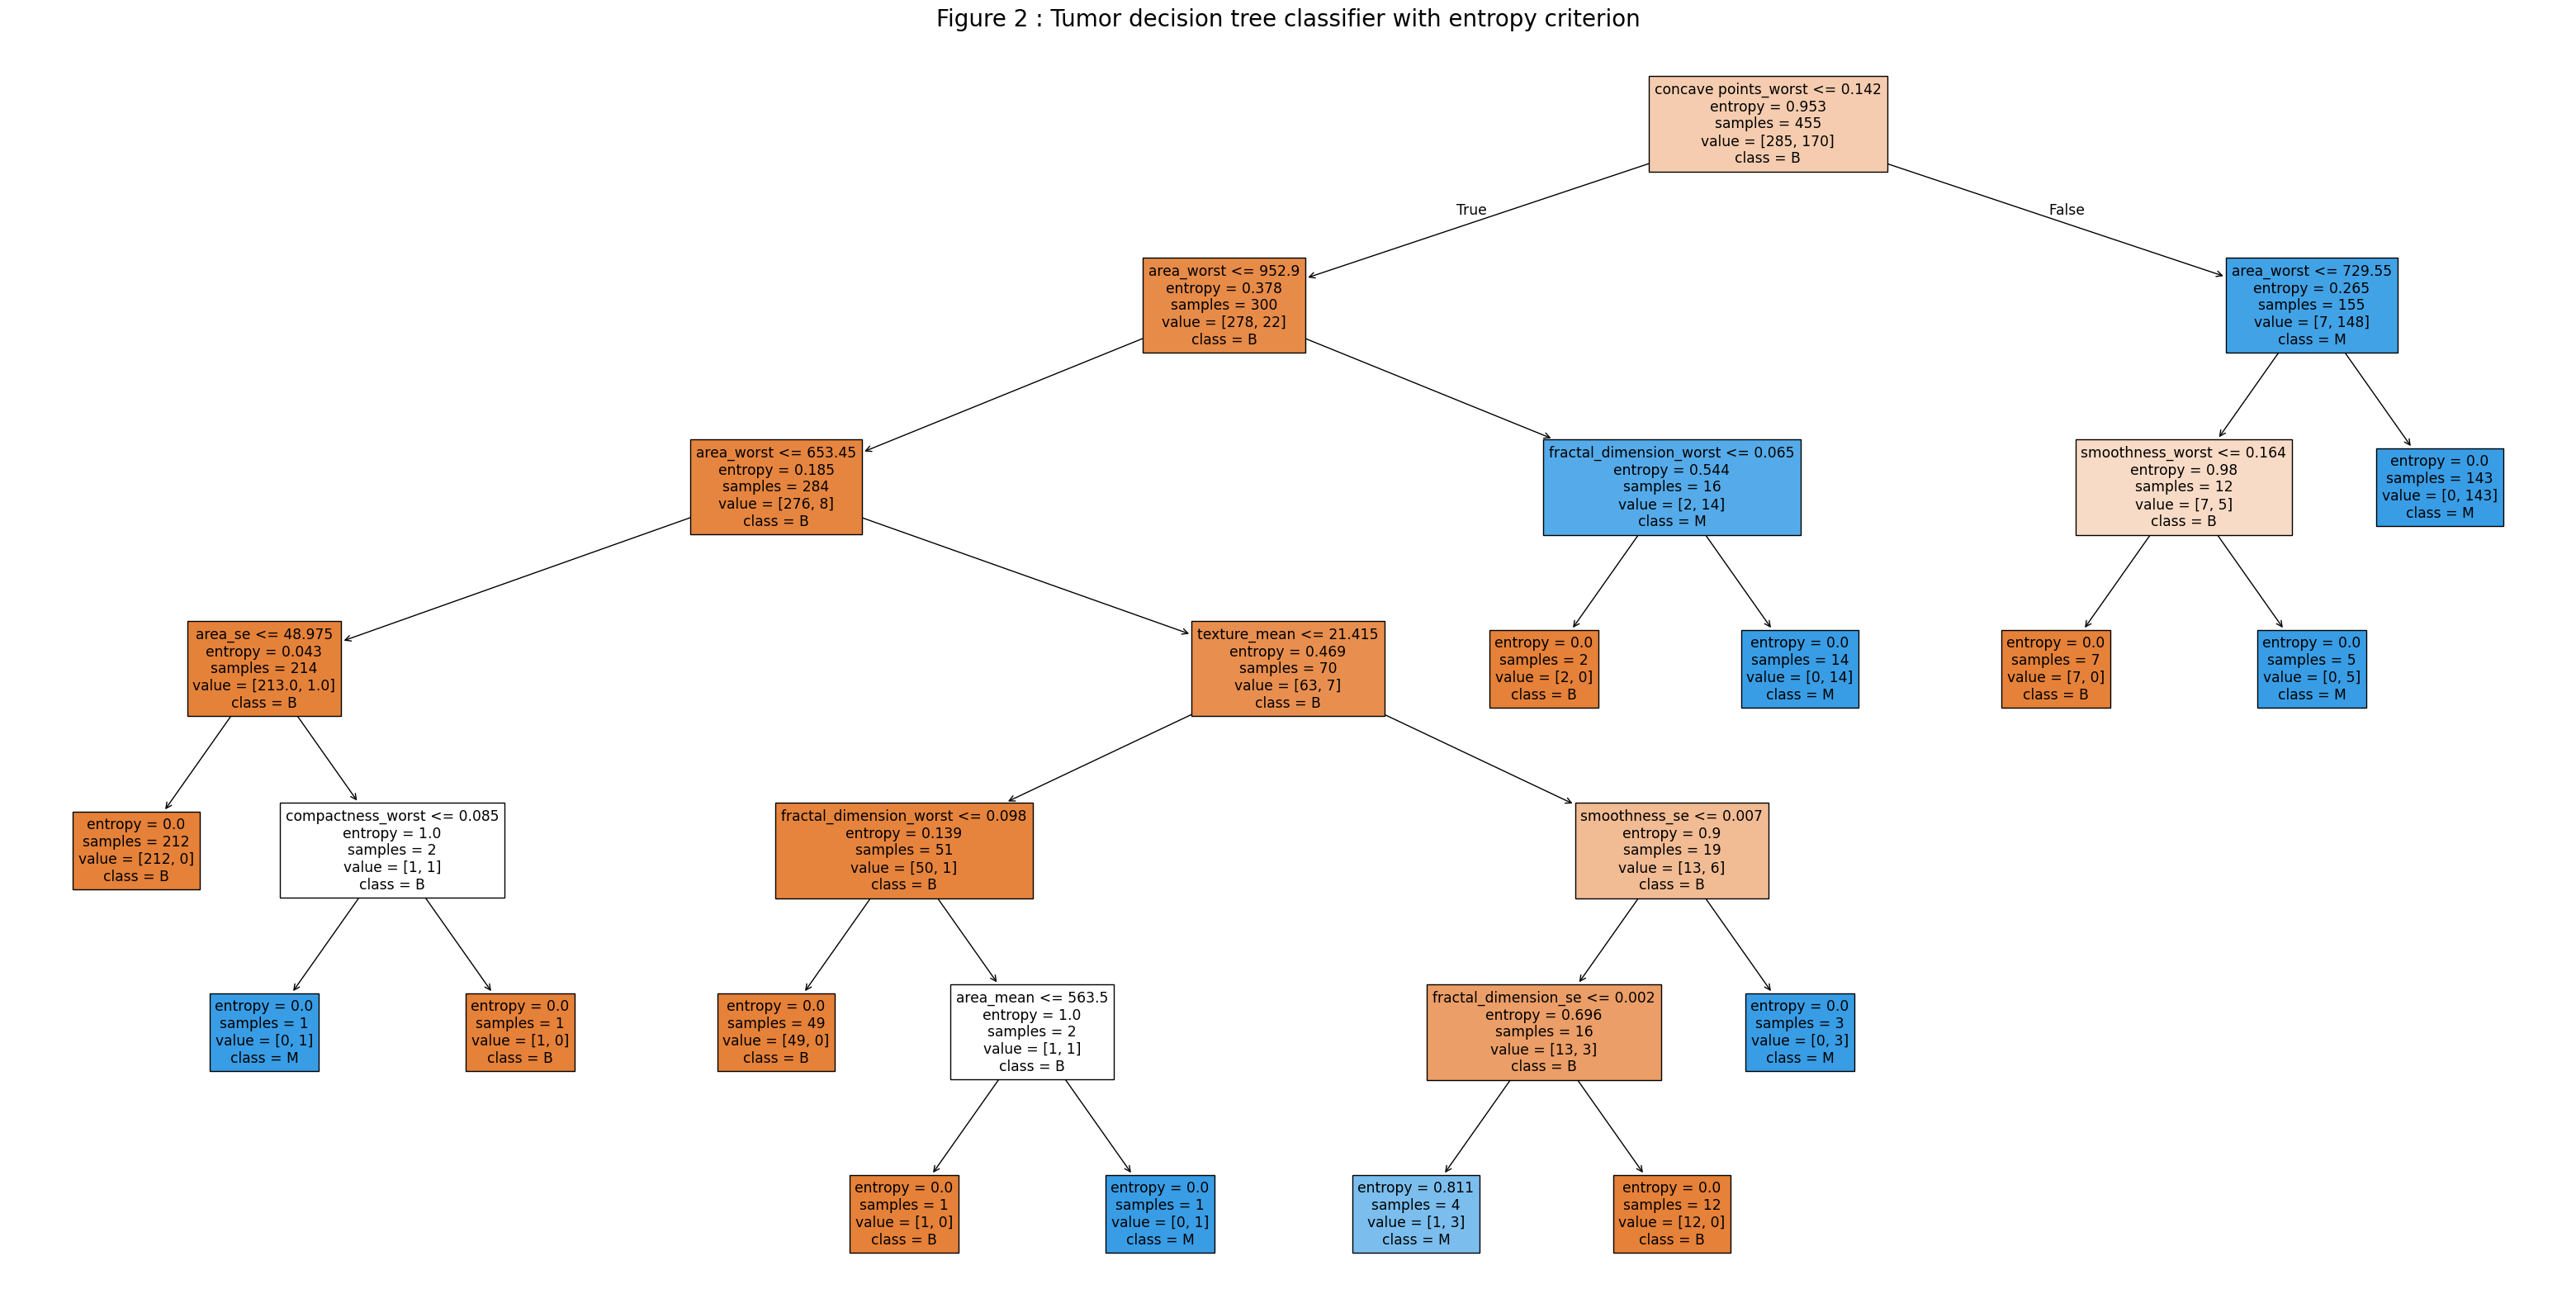

In [58]:
# Plot the decision tree with entropy criterion
plt.figure(figsize=(40,20))

plot_tree(dt2, max_depth= 6, feature_names= features2, class_names= class_labels2, label='all',filled=True, impurity=True, 
          node_ids=False, proportion=False, rounded=False, precision=3, ax=None, fontsize=None)

plt.title("Figure 2 : Tumor decision tree classifier with entropy criterion", fontsize=20)

plt.savefig("Figure2_Tumor_decision_tree_classifier_entropy.png", dpi=300, bbox_inches='tight')

plt.show()

### Figure 2: Tumor classification Using a decision tree with Entropy criterion

This figure presents a **decision tree classifier** trained to predict tumor type — **Benign (B)** or **Malignant (M)** — using the **entropy criterion** as the splitting metric. Each internal node represents a binary decision based on a feature threshold, while each leaf node indicates a final classification outcome.

#### Node details:
- **Entropy**: Measures the impurity or disorder at each node; values close to 0 represent pure nodes (mostly one class), while values near 1 indicate mixed classes.
- **Samples**: Number of observations that reach the node.
- **Value**: Distribution of samples by class: `[Benign, Malignant]`.
- **Class**: The predicted class at the node.

#### Key insights:
- The **root node** splits on `concave points_worst`, indicating it is the most informative feature for this model.
- The left subtree classifies primarily **Benign tumors**, using features such as `area_worst`, `texture_mean`, and `fractal_dimension_worst`.
- The right subtree captures more **Malignant cases**, especially where `area_worst` exceeds 729.55.
- The tree depth is moderate, and most terminal nodes are **pure** (entropy = 0), suggesting a high-confidence prediction.
- This structure supports **transparent, rule-based decision-making**, which is valuable in clinical settings where **model interpretability** is essential.

While entropy allows more nuanced splits than Gini impurity in some cases, it may also result in slightly more complex trees. This model offers a balance between **predictive performance** and **interpretability** for medical diagnostics.


In [59]:
# Instantiate a DecisionTreeClassifier with gini criterion
dt3= DecisionTreeClassifier(max_depth=6, criterion= 'gini', random_state=6)

# Fit dt to the training set
dt3.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=6)

In [60]:
# Retrieve class names corresponding to diagnosis
class_labels3= dt3.classes_

In [61]:
# Predict the test set labels
y_pred= dt3.predict(X_test)

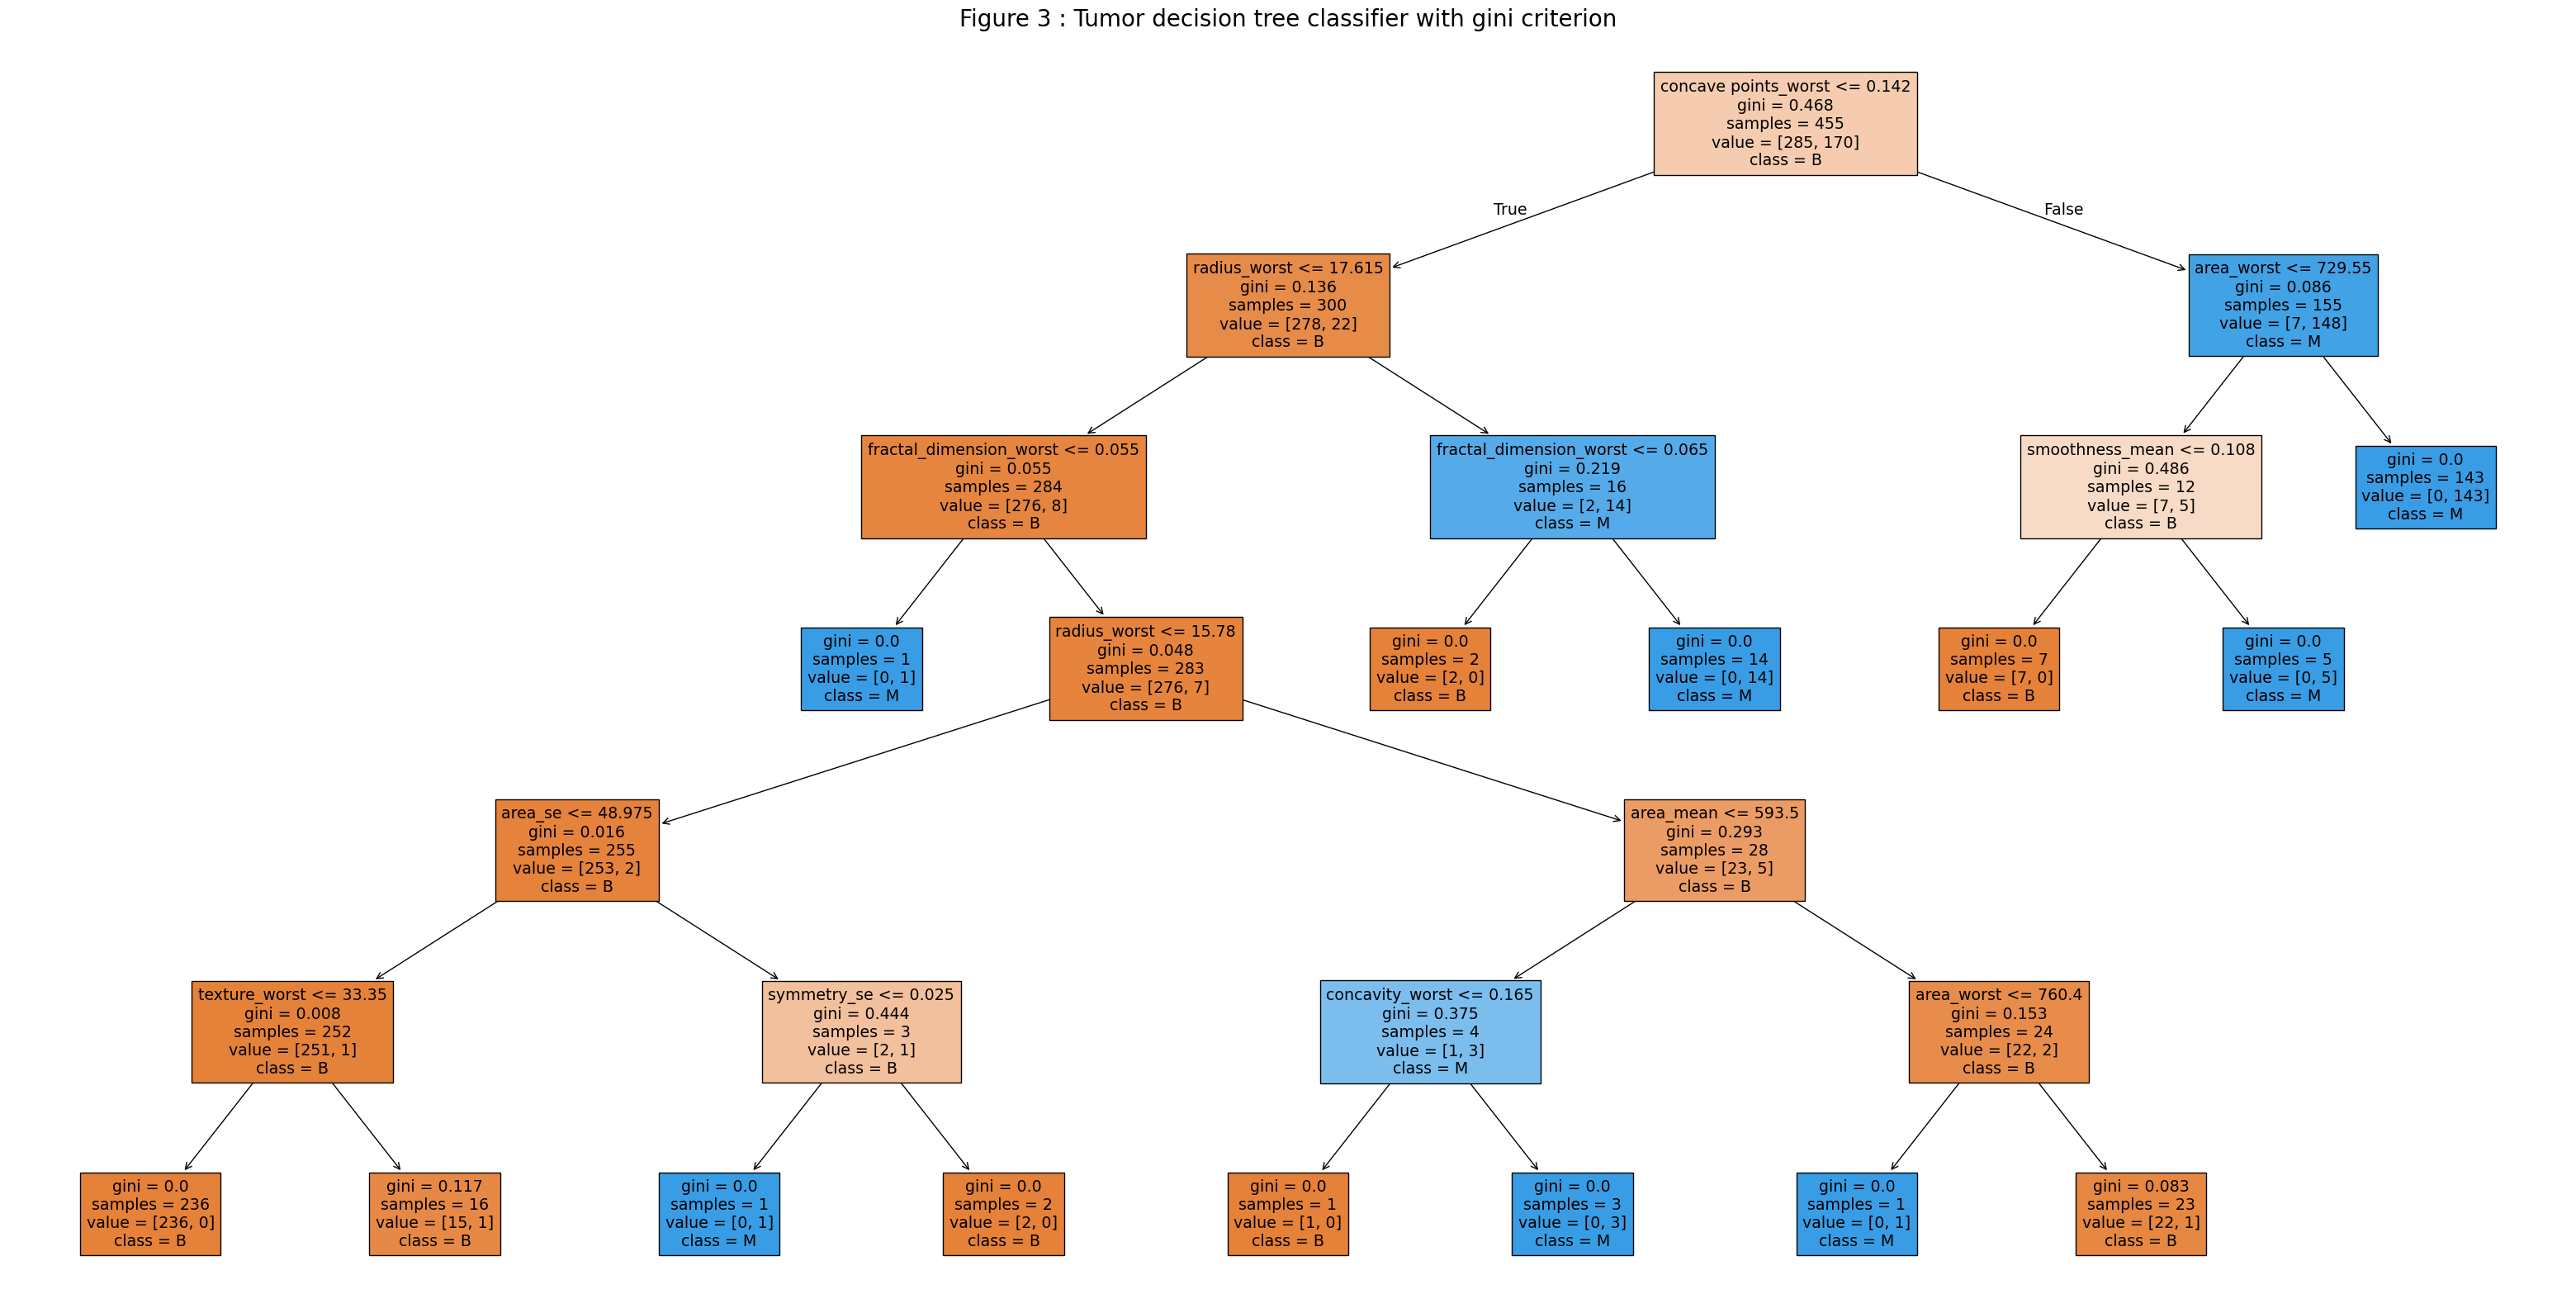

In [62]:
# Plot the decision tree with gini criterion
plt.figure(figsize=(40,20))

plot_tree(dt3, max_depth= 6, feature_names= features2, class_names= class_labels3, label='all',filled=True, impurity=True, 
          node_ids=False, proportion=False, rounded=False, precision=3, ax=None, fontsize=None)

plt.title("Figure 3 : Tumor decision tree classifier with gini criterion", fontsize=20)

plt.savefig("Figure3_Tumor_decision_tree_classifier_gini.png", dpi=300, bbox_inches='tight')

plt.show()

### Figure 3: Decision tree classifier using Gini impurity

This figure shows a decision tree trained to classify tumors as **Benign (B)** or **Malignant (M)** using the **Gini impurity** criterion. The tree is based on clinical features such as `radius_worst`, `area_worst`, and `concave points_worst`.

- The **Gini index** at each node measures class impurity (0 = pure). Most terminal nodes in this tree show low Gini values, indicating confident classification.
- Internal nodes include thresholds for splits, sample counts, class distributions, and the predicted class.
- The root node splits on `concave points_worst`, suggesting it's the most discriminative feature in the dataset.

Compared to an entropy-based tree, this version achieves similar interpretability with slightly different branching. It leans more on `radius_worst` and `texture_worst` in early splits, reflecting how Gini may prioritize different paths when optimizing for class separation.

The model remains interpretable and suitable for scenarios where explainability is required, particularly in diagnostic settings.


[ENG]

7. Compare the two approaches using the previous performance metric

[FR]

7. Comparez les deux approches en utilisant la métrique de performance précédente

In [63]:
# Use dt2 having the Entropy criterion to predict test set labels
y_pred= dt2.predict(X_test)

# Evaluation the Entropy criterion
accuracy_entropy= accuracy_score(y_test, y_pred)

# Print accuracy_entropy
print(f"Accuracy achieved by using entropy {accuracy_entropy:.3f}")

Accuracy achieved by using entropy 0.912


In [64]:
# Use dt3 having the Gini criterion to predict test set labels
y_pred= dt3.predict(X_test)

# Evaluation the Entropy criterion
accuracy_gini= accuracy_score(y_test, y_pred)

# Print accuracy_entropy
print(f"Accuracy achieved by using gini {accuracy_gini:.3f}")

Accuracy achieved by using gini 0.886


We can observe that the **entropy** criterion achieves nearly **92% accuracy**, while the **gini** criterion reaches about **89% accuracy**.

In this case, the **entropy** criterion is the better choice, especially given the context: the goal is to accurately classify **benign** and **malignant** cancer tumors.  
Higher accuracy and a more detailed consideration of uncertainty make entropy more suitable for such critical medical applications.


[ENG]

EXERCISE 3: PERFORMANCE METRICS

[FR]

EXERCICE 3 : METRIQUES DE PERFORMANCE

In [65]:
# Packages
import seaborn as sns

### Performance metrics

#### 1. Accuracy
**Definition:**  
Accuracy measures the percentage of correct predictions out of all predictions made.  
While straightforward, accuracy can be misleading if the dataset is imbalanced (e.g., one class is much more common than others).

**Formula:**  
$$
\text{Accuracy} = \frac{\text{True Positives} + \text{True Negatives}}{\text{Total Number of Samples}}
$$

**Advantages:**
- **Simple to understand:** Easy to interpret and calculate.
- **Overall performance:** Provides a quick snapshot of model performance.

**Disadvantages:**
- **Misleading with imbalanced data:** High accuracy can occur even with poor model performance if one class dominates.
- **Doesn’t differentiate errors:** Treats all errors equally, without considering the cost of different types of mistakes.

**Best use:**  
Suitable for balanced datasets where all errors are equally important.

---

#### 2. Recall (Sensitivity or True Positive Rate)
**Definition:**  
Recall measures the model’s ability to find all positive instances in the dataset.

**Formula:**  
$$
\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}
$$

**Advantages:**
- **Focuses on False Negatives:** Essential when missing positive cases has a high cost (e.g., disease detection).
- **Good for imbalanced data:** Helps when the minority class is important.

**Disadvantages:**
- **Ignores False Positives:** May cause many unnecessary positive predictions if used alone.

**Best use:**  
When missing positive cases (false negatives) is costly, such as in medical diagnostics or fraud detection.

---

#### 3. Precision
**Definition:**  
Precision measures the accuracy of positive predictions — the proportion of true positives out of all predicted positives.

**Formula:**  
$$
\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
$$

**Advantages:**
- **Focuses on False Positives:** Critical where false positives are costly (e.g., spam detection, fraud detection).
- **Better for imbalanced data:** Emphasizes correct positive predictions.

**Disadvantages:**
- **Ignores False Negatives:** Does not address missing positive cases.

**Best Use:**  
When false positives are costly and precision is a priority.

---

#### 4. Sensitivity (Recall)
**Definition:**  
Sensitivity is another term for Recall. It measures the proportion of actual positives that are correctly identified.

**Formula:**  
$$
\text{Sensitivity} = \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}
$$

---

#### 5. Specificity
**Definition:**  
Specificity measures the proportion of actual negatives that are correctly identified (true negatives).

**Formula:**  
$$
\text{Specificity} = \frac{\text{True Negatives}}{\text{True Negatives} + \text{False Positives}}
$$

**Advantages:**
- **Focuses on True Negatives:** Important where avoiding false positives is critical.
- **Complements Sensitivity:** Together, they provide a full picture of model performance.

**Disadvantages:**
- **Ignores False Negatives:** Does not assess the ability to detect positive cases.

**Best use:**  
When false positives are costly (e.g., medical screening, rare-event detection).

---

#### 6. F1 Score
**Definition:**  
The F1 Score is the harmonic mean of Precision and Recall, balancing both concerns.

**Formula:**  
$$
\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**Advantages:**
- **Balances Precision and Recall:** Useful when both false positives and false negatives are important.
- **Good for imbalanced data:** Effective for evaluating performance where class distribution is uneven.

**Disadvantages:**
- **Harder to interpret:** Not as intuitive as accuracy.
- **Not always the best metric:** If either precision or recall is much more important, F1 may not fully reflect the priority.

**Best use:**  
When both precision and recall are critical, especially with imbalanced classes.

---

#### 7. AUC (Area Under the Curve)
**Definition:**  
AUC measures the ability of the model to distinguish between positive and negative classes. It is based on the ROC (Receiver Operating Characteristic) curve.

**Advantages:**
- **Threshold-independent:** Considers all possible classification thresholds.
- **Effective in imbalanced datasets:** Offers a more robust evaluation compared to accuracy.

**Disadvantages:**
- **Less intuitive:** Harder to directly interpret than accuracy or precision.
- **Focuses on ranking, not direct classification:** Evaluates ranking ability rather than precise label prediction.

**Best use:**  
When comparing multiple models or evaluating models on imbalanced datasets, especially when different thresholds matter.

---



[ENG]

1. Find a way to display the confusion matrix of the model (we will pay particular attention to the aesthetics of this matrix)

[FR]

1. Trouvez une méthode pour afficher la matrice de confusion du modèle (nous porterons une attention toute particulière à l’esthétisme de cette matrice)

In [66]:
# Confusion Matrix
conf_matrix= confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()


print('Confusion Matrix : \n',conf_matrix)

Confusion Matrix : 
 [[67  5]
 [ 8 34]]


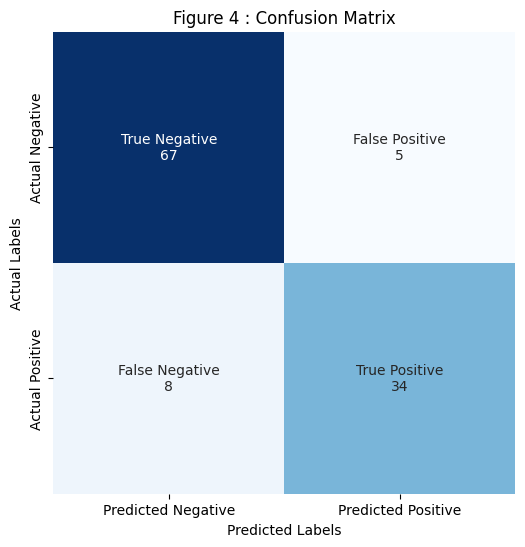

In [67]:
# Create a list of labels and numbers for the confusion matrix
combined_labels = np.array([
    [f"True Negative\n{tn}", f"False Positive\n{fp}"],
    [f"False Negative\n{fn}", f"True Positive\n{tp}"]
])

# Create the matrix with text
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=combined_labels, fmt='', cmap='Blues', cbar=False, square=True,
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])

# Customize plot labels
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Figure 4 : Confusion Matrix")

plt.savefig("Figure4_confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()

### Figure 4: Confusion matrix – Model performance on test set

This confusion matrix summarizes the classification results of the model on the test dataset. The model distinguishes between two classes: **Negative (Benign)** and **Positive (Malignant)**.

- **True Negatives (TN):** 67 samples correctly identified as Negative
- **True Positives (TP):** 34 samples correctly identified as Positive
- **False Positives (FP):** 5 samples incorrectly labeled as Positive
- **False Negatives (FN):** 8 samples incorrectly labeled as Negative

#### Performance Indicators (based on this matrix):
- **Accuracy:** `(67 + 34) / (67 + 5 + 8 + 34) ≈ 0.90`
- **Precision (Positive class):** `34 / (34 + 5) ≈ 0.87`
- **Recall (Positive class):** `34 / (34 + 8) ≈ 0.81`

These results indicate that the model performs well overall, with relatively low false positive and false negative rates. However, the cost of false negatives in medical diagnostics (i.e. missing a malignant tumor) may warrant further tuning or threshold adjustment, depending on deployment context.


In [78]:
# Calculate Accuracy
accuracy= (tp + tn) / 114
print (f'The confusion matrix accuracy ratio is {accuracy * 100:.2f}%')

The confusion matrix accuracy ratio is 88.60%


In [79]:
# Calculate Precision

precision= tp / (tp + fp)

print(f'The ratio of true positives to all positive predictions is: {precision * 100:.2f}%')

The ratio of true positives to all positive predictions is: 87.18%


In [80]:
# Calculate Sensitivity (Recall)
recall= tp / (tp+ fn)

print(f'The proportion of positive samples correctly classified as positive : {recall * 100:.2f}%')

The proportion of positive samples correctly classified as positive : 80.95%


In [81]:
# Calculate specificity
specificity = tn / (tn + fp)
print(f'The proportion of actual negative samples correctly classified as negative: {specificity * 100:.2f}%')

The proportion of actual negative samples correctly classified as negative: 93.06%


In [82]:
# Calculate F1 score
f1_score= 2*((precision * recall)/(precision + recall))
print(f'The harmonic mean of Precision and Recall is: {f1_score * 100:.2f}%')

The harmonic mean of Precision and Recall is: 83.95%


### Evaluation Metrics from Confusion Matrix

The following metrics were calculated based on the test set predictions:

- **Accuracy:** 88.60%  
  Proportion of total samples correctly classified, both positive and negative.

- **Precision (Positive Predictive Value):** 87.18%  
  Of all samples predicted as positive (malignant), 87.18% were truly positive.

- **Recall (Sensitivity):** 80.95%  
  Of all actual positive (malignant) cases, 80.95% were correctly identified by the model.

- **Specificity:** 93.06%  
  The model correctly classified 93.06% of actual negative (benign) samples.

- **F1 Score:** 83.95%  
  Harmonic mean of precision and recall, useful when seeking a balance between false positives and false negatives.

These metrics suggest the model performs reliably, with strong specificity and precision. Slightly lower recall indicates that some positive cases are still being missed, which could be important to address in a clinical context.


[ENG]

2. Display the ROC curve and the corresponding AUC. For the record, we show an example of an ROC curve below. For what values AUC values is a model relatively useless, or on the contrary very efficient? Why is there a trade-off between false positive rate and true positive rate?

[FR]

2. Affichez la courbe ROC et l’AUC correspondant. Pour mémoire, nous montrons un exemple de courbe ROC ci-dessous. Pour quelles valeurs d’AUC un modèle est-il relativement inutile, ou au contraire très performant ? Pourquoi y a-t-il un compromis (trade-off) entre taux de faux positifs et taux de vrais positifs ?

In [68]:
# Counts from confusion matrix
tn, fp, fn, tp = 66, 6, 8, 34

# Construct y_true array
y_true = np.array([0] * (tn + fp) + [1] * (fn + tp))

# Use dt2, since entropy criterion is better, to predict probabilities
y_score= dt2.predict_proba(X_test)[:, 1]

In [69]:
# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_score)

In [70]:
# Calculate the AUC
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")

AUC: 0.52


In [71]:
# Calculate the AUC (version 2)
roc_auc2 = roc_auc_score(y_true, y_score)
print(f"AUC: {roc_auc2:.2f}")

AUC: 0.52


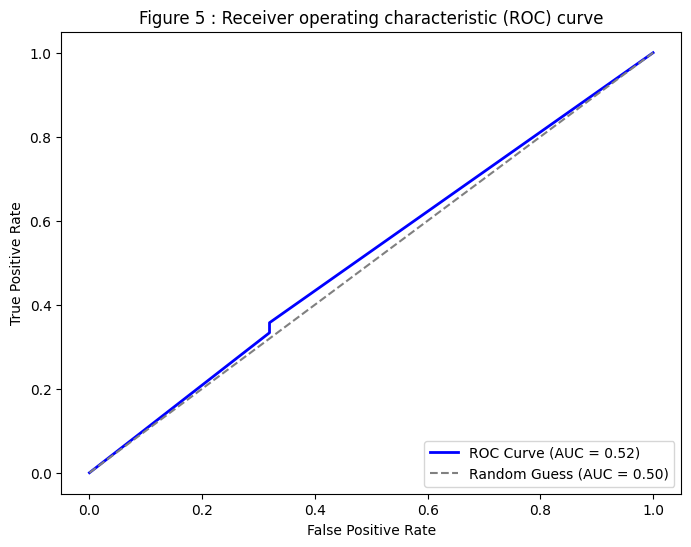

In [87]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.50)')  # Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 5 : Receiver operating characteristic (ROC) curve")
plt.legend(loc="lower right")

plt.savefig("Figure5_receiver_operating_characteristic_(ROC)_curve.png", dpi=300, bbox_inches='tight')

plt.show()

### Interpreting AUC

A model becomes **useless** when **AUC = 0.5**.  
This would mean the model has no discrimination ability — its predictions are equivalent to random guessing (the ROC curve would be a 45-degree diagonal line).  

The closer the AUC is to **1**, the more efficient the model becomes.  
A model with **AUC = 1** would be a **perfect classifier**, meaning it could fully separate positive and negative instances at all thresholds.

---

#### TPR and FPR trade-off

There is a **trade-off** between the **True Positive Rate (TPR)** and the **False Positive Rate (FPR)**.  
This trade-off arises because of the decision thresholds used to classify probabilities in a binary classification model.  
It can be visualized on the ROC curve, showing how the model reacts to different levels of **sensitivity** and **specificity**.

- **Low threshold** (e.g., 0.2):
  - The model is more tolerant, classifying many samples as positive, even those with low probability.
  - **TPR rises**: More true positives are detected (fewer false negatives).
  - **FPR rises**: More negatives are incorrectly classified as positives (more false positives).

- **High threshold** (e.g., 0.8):
  - The model is more stringent, classifying only samples with high positive scores.
  - **FPR decreases**: True negatives are more accurately classified.
  - **TPR decreases**: Some true positives are missed (more false negatives).

This trade-off occurs because models are not perfect — they cannot perfectly separate positive and negative classes.

**Key insights:**
- To maximize **sensitivity** (detecting positives), we often have to tolerate a rise in **false positives**.
- To maximize **specificity** (correctly identifying negatives), we risk missing some positive cases.
- **Sensitivity** and **specificity** are often conflicting: improving one can worsen the other.
- Understanding and adjusting this trade-off allows tuning the model depending on the goals of the exercise (e.g., favoring sensitivity in disease detection or specificity in fraud prevention).



[ENG]

3. Display the Precision-Recall curve and the corresponding AUC P-R. What is the difference between sensitivity and recall in the case of binary classification? classification? Why is there a trade-off between recall and precision?

[FR]

3. Affichez la courbe Precision-Recall et l’AUC P-R correspondant. Quelle différence entre sensibilité et rappel dans le cas d’une classification binaire ? Pourquoi y a-t-il un compromis (trade-off) entre rappel et precision ?

In [72]:
# Step 1: Calculate precision, recall, thresholds
precision_array, recall_array, threshold_array = precision_recall_curve(y_true, probas_pred=y_score)

# Step 2: Compute the AUC for the Precision-Recall curve
auc_pr = auc(recall_array, precision_array)

c:\Users\emmhu\anaconda3\envs\Bac_a_sable\Lib\site-packages\sklearn\metrics\_ranking.py:993: FutureWarning: probas_pred was deprecated in version 1.5 and will be removed in 1.7.Please use ``y_score`` instead.
  warnings.warn(


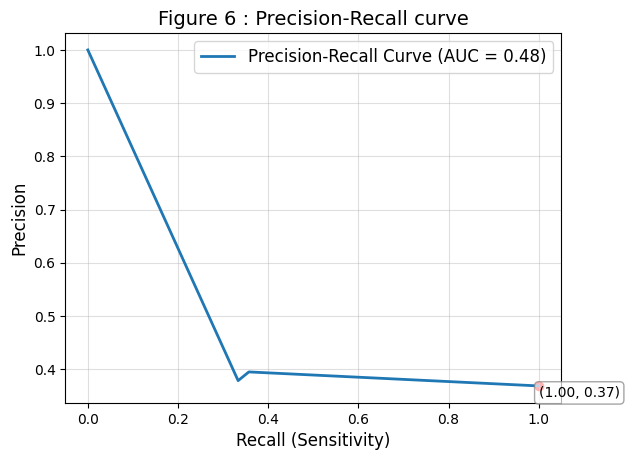

In [73]:
# Step 3: Plot the Precision-Recall Curve
plt.plot(recall_array, precision_array, label=f"Precision-Recall Curve (AUC = {auc_pr:.2f})", linewidth=2)
plt.xlabel("Recall (Sensitivity)", fontsize=12) 
plt.ylabel("Precision", fontsize=12)             
plt.title("Figure 6 : Precision-Recall curve", fontsize=14)

# Step 4: Add grid and legend
plt.grid(alpha=0.4)                             
plt.legend(fontsize=12)                        

# Step 5: Annotate Key Points
# Annotating the first point
plt.scatter(recall_array[0], precision_array[0], color='red', label="Start Point")
plt.text(recall_array[0], precision_array[0], 
         f"({recall_array[0]:.2f}, {precision_array[0]:.2f})", 
         fontsize=10, 
         ha='left', va='top', 
         bbox=dict(boxstyle="round,pad=0.3", edgecolor='gray', facecolor='white', alpha=0.7))

plt.savefig("Figure6_precision_recall_curve.png", dpi=300, bbox_inches='tight')

plt.show()

### Figure 6 : Precision-Recall Curve

#### 1. Curve shape and interpretation

- **Vertical drop (Near 0 Recall):**  
  The curve starts at the top-left, where precision is 1.0 at very low recall.  
  This suggests that, at a high threshold, the model is highly precise but identifies very few true positives, resulting in low recall.  
  This part of the curve represents high-confidence predictions with limited positive detection.

- **Sharp decline in precision:**  
  As recall increases slightly, precision drops steeply.  
  This indicates that as the model becomes more aggressive (lowering the threshold to identify more positives), it also misclassifies more negatives as positives, reducing precision significantly.

- **Plateau at low precision (0.35–0.40):**  
  The curve stabilizes around a precision of 0.35–0.40 as recall gradually increases toward 1.0.  
  This plateau reflects the model’s behavior at lower thresholds, where it predicts more positives but at the cost of many false positives.

---

#### 2. AUC-PR value (AUC = 0.48)

The Area Under the Curve for Precision-Recall (AUC-PR) is **0.48**, which is low.  
- In general, an AUC-PR close to **1.0** indicates a strong model, while a value near **0.5** suggests performance close to random guessing.  
- An AUC-PR of **0.48** suggests limited discriminatory power, likely struggling to separate positives from negatives effectively.

---

#### 3. Annotation at (1.00, 0.37)

- The annotation at **(1.00, 0.37)** marks the endpoint of the curve where recall reaches **1.0**, meaning the model detects all true positives.  
- However, precision at this point is only **0.37**, indicating a **high false positive rate**.  
- Although the model captures all positives, it misclassifies many negatives as positives, significantly reducing precision.

---

#### 4. Practical implications

- The shape of the PR curve suggests the model might be **overfitting to the negative class** or lacks **discriminative power**.
- **If precision is critical** (e.g., medical diagnosis, fraud detection), the model’s performance is inadequate because of the high false positive rate.
- **If recall is prioritized** (e.g., flagging all possible fraud cases), the model achieves full recall, but the low precision would require additional filtering afterward.

---

#### Recommendations for improvement

- **Optimize the decision threshold:**  
  Fine-tune the threshold to find a better trade-off between precision and recall depending on the application.

- **Try alternative models:**  
  Experiment with models better suited for handling imbalanced data or capturing complex patterns.

- **Apply resampling techniques:**  
  Use methods such as **oversampling** the minority class or **undersampling** the majority class if the dataset is imbalanced.

- **Improve feature engineering:**  
  Create new features or select more relevant ones to help the model better distinguish between classes.

---

#### Conclusion

The PR curve and AUC-PR score of **0.48** reveal that the current model struggles to maintain high precision while achieving high recall.  
This diagnostic suggests **significant room for improvement** before the model would be suitable for real-world deployment.  
Steps such as adjusting the threshold, tuning the model, improving data balance, or enhancing features could help improve its performance.



### Difference between Sensitivity and Recall in binary classification

In the context of binary classification, **Sensitivity** and **Recall** are synonyms.  
Both measure the same thing: **the model’s ability to correctly identify positive cases**.  
This corresponds to the proportion of true positives correctly detected among all actual positive cases.

---

### Why Is There a trade-off between Recall and Precision?

The trade-off between **recall** and **precision** exists because changing the decision threshold to maximize one usually **reduces the other**:
- **Increasing recall** (capturing more true positives) often comes at the cost of more false positives, thus lowering precision.
- **Increasing precision** (reducing false positives) may cause the model to miss more true positives, thus lowering recall.

The best trade-off depends on the specific application goals:
- **Favor recall** when minimizing false negatives is critical (e.g., detecting diseases).
- **Favor precision** when minimizing false positives is more important (e.g., spam filtering or critical decision-making).

